Hola **Jimena**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

## Modelos de Regresión. Algoritmo de descenso de gradiente. Potenciación del gradiente.

El servicio de venta de autos usados Rusty Bargain está desarrollando una aplicación para atraer nuevos clientes. Gracias a esa app, puedes averiguar rápidamente el valor de mercado de tu coche. Tienes acceso al historial: especificaciones técnicas, versiones de equipamiento y precios. Tienes que crear un modelo que determine el valor de mercado.
A Rusty Bargain le interesa:
- la calidad de la predicción;
- la velocidad de la predicción;
- el tiempo requerido para el entrenamiento

## Preparacion de datos.


Empecemos cargando las librerías necesarias para analizar la base de datos y poder correr los modelos de predicción. 

Después hacer una revision y limpieza de las columnas, tipos de datos, valores duplicados y valores asuentes. 

Una vez terminando podemos empezar con el analisis de la base de datos y entender más los datos proporcionados. 

In [206]:
#Cargar librerias para el desarrollo del proyecto. 
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.metrics import r2_score
from catboost import CatBoostRegressor
import time
import xgboost as xgb
import time 
import lightgbm as lgb

In [207]:
cars_database = pd.read_csv('database\car_data.csv')
cars_database.info()

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\jimen\AppData\Local\Temp\ipykernel_21048\1636723896.py:1: SyntaxWarning: invalid escape sequence '\c'
  cars_database = pd.read_csv('database\car_data.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, carga de datos e importación de librerías bien hecha! 
</div>

In [208]:
new_col = []
for old_name in cars_database.columns:
    name_lower = old_name.lower()
    new_col.append(name_lower)
cars_database.columns = new_col

In [209]:
cars_database['price'] = cars_database['price'].astype('float64')
#cars_database['registrationmonth'] = cars_database['registrationmonth'].astype('str')
#cars_database['postalcode'] = cars_database['postalcode'].astype('str')
"""cars_database['datecrawled'] = pd.to_datetime(cars_database['datecrawled'],
                                                   format= "%d/%m/%Y %H:%M")
cars_database['datecreated'] = pd.to_datetime(cars_database['datecreated'],
                                                   format= "%d/%m/%Y %H:%M")
cars_database['lastseen'] = pd.to_datetime(cars_database['lastseen'],
                                                   format= "%d/%m/%Y %H:%M")
"""
cars_database.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   datecrawled        354369 non-null  object 
 1   price              354369 non-null  float64
 2   vehicletype        316879 non-null  object 
 3   registrationyear   354369 non-null  int64  
 4   gearbox            334536 non-null  object 
 5   power              354369 non-null  int64  
 6   model              334664 non-null  object 
 7   mileage            354369 non-null  int64  
 8   registrationmonth  354369 non-null  int64  
 9   fueltype           321474 non-null  object 
 10  brand              354369 non-null  object 
 11  notrepaired        283215 non-null  object 
 12  datecreated        354369 non-null  object 
 13  numberofpictures   354369 non-null  int64  
 14  postalcode         354369 non-null  int64  
 15  lastseen           354369 non-null  object 
dtypes:

In [210]:
display(cars_database.head())

,datecrawled,price,vehicletype,registrationyear,gearbox,power,model,mileage,registrationmonth,fueltype,brand,notrepaired,datecreated,numberofpictures,postalcode,lastseen
0,24/03/2016 11:52,480.0,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300.0,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800.0,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500.0,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600.0,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17


In [211]:
print('Tenemos en las siguientes columnas ausentes:\n',cars_database.isna().sum())
print('\nTenemos los siguientes datos duplicados: \n',cars_database.duplicated().sum())

Tenemos en las siguientes columnas ausentes:
 datecrawled              0
price                    0
vehicletype          37490
registrationyear         0
gearbox              19833
power                    0
model                19705
mileage                  0
registrationmonth        0
fueltype             32895
brand                    0
notrepaired          71154
datecreated              0
numberofpictures         0
postalcode               0
lastseen                 0
dtype: int64

Tenemos los siguientes datos duplicados: 
 262


Las siguientes columnas tienen valores valores ausentes, revisemos que valores unicos tienen para entender mejor sus valores. 

In [212]:
print(cars_database['vehicletype'].unique())
print(cars_database['gearbox'].unique())
print(cars_database['model'].unique())
print(cars_database['fueltype'].unique())
print(cars_database['notrepaired'].unique())

[nan 'coupe' 'suv' 'small' 'sedan' 'convertible' 'bus' 'wagon' 'other']
['manual' 'auto' nan]
['golf' nan 'grand' 'fabia' '3er' '2_reihe' 'other' 'c_max' '3_reihe'
 'passat' 'navara' 'ka' 'polo' 'twingo' 'a_klasse' 'scirocco' '5er'
 'meriva' 'arosa' 'c4' 'civic' 'transporter' 'punto' 'e_klasse' 'clio'
 'kadett' 'kangoo' 'corsa' 'one' 'fortwo' '1er' 'b_klasse' 'signum'
 'astra' 'a8' 'jetta' 'fiesta' 'c_klasse' 'micra' 'vito' 'sprinter' '156'
 'escort' 'forester' 'xc_reihe' 'scenic' 'a4' 'a1' 'insignia' 'combo'
 'focus' 'tt' 'a6' 'jazz' 'omega' 'slk' '7er' '80' '147' '100' 'z_reihe'
 'sportage' 'sorento' 'v40' 'ibiza' 'mustang' 'eos' 'touran' 'getz' 'a3'
 'almera' 'megane' 'lupo' 'r19' 'zafira' 'caddy' 'mondeo' 'cordoba' 'colt'
 'impreza' 'vectra' 'berlingo' 'tiguan' 'i_reihe' 'espace' 'sharan'
 '6_reihe' 'panda' 'up' 'seicento' 'ceed' '5_reihe' 'yeti' 'octavia' 'mii'
 'rx_reihe' '6er' 'modus' 'fox' 'matiz' 'beetle' 'c1' 'rio' 'touareg'
 'logan' 'spider' 'cuore' 's_max' 'a2' 'galaxy' 'c3

In [213]:
#Eliminar los valores ausentes y duplicados
cars_database = cars_database.drop_duplicates().reset_index(drop= True)
cars_database = cars_database.dropna().reset_index(drop= True)
print('Tenemos en las siguientes columnas ausentes:\n',cars_database.isna().sum())
print('\nTenemos los siguientes datos duplicados: \n',cars_database.duplicated().sum())

Tenemos en las siguientes columnas ausentes:
 datecrawled          0
price                0
vehicletype          0
registrationyear     0
gearbox              0
power                0
model                0
mileage              0
registrationmonth    0
fueltype             0
brand                0
notrepaired          0
datecreated          0
numberofpictures     0
postalcode           0
lastseen             0
dtype: int64

Tenemos los siguientes datos duplicados: 
 0


In [214]:
print(cars_database.nunique())

datecrawled          14790
price                 3405
vehicletype              8
registrationyear        83
gearbox                  2
power                  540
model                  249
mileage                 13
registrationmonth       13
fueltype                 7
brand                   39
notrepaired              2
datecreated            103
numberofpictures         1
postalcode            8073
lastseen             16683
dtype: int64


In [215]:
cars_database.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245567 entries, 0 to 245566
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   datecrawled        245567 non-null  object 
 1   price              245567 non-null  float64
 2   vehicletype        245567 non-null  object 
 3   registrationyear   245567 non-null  int64  
 4   gearbox            245567 non-null  object 
 5   power              245567 non-null  int64  
 6   model              245567 non-null  object 
 7   mileage            245567 non-null  int64  
 8   registrationmonth  245567 non-null  int64  
 9   fueltype           245567 non-null  object 
 10  brand              245567 non-null  object 
 11  notrepaired        245567 non-null  object 
 12  datecreated        245567 non-null  object 
 13  numberofpictures   245567 non-null  int64  
 14  postalcode         245567 non-null  int64  
 15  lastseen           245567 non-null  object 
dtypes:

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Buen trabajo con la revisión inicial de los datos, este paso aunque repetitivo en cada proyecto es muy importante para poder entender desde un inicio los datos
</div>

Empecemos a revisar los datos para entender que vehículos son los mas caros, cuantos tipos de carros tenemos, cuantos han requeridos reparaciones, etc. 

Para ello agruparemos los datos y realizaremos operaciones para identificar las cantidades. De igual forma se mostraran las graficas para una mejor observación. 

Cantidad de Tipos de vehiculos... 
 vehicletype
other           1740
suv             9634
coupe          12206
convertible    16185
bus            23626
wagon          51122
small          58852
sedan          72202
Name: price, dtype: int64

Promedio de los precios de los tipos de vehiculos... 
 vehicletype
small          3046.202253
other          3924.416092
sedan          5129.084444
wagon          5382.705665
bus            5818.373106
coupe          6581.342127
convertible    7305.534013
suv            9451.200955
Name: price, dtype: float64


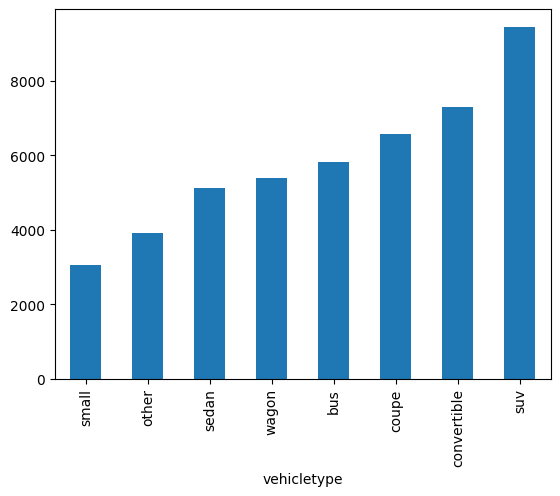

In [216]:
vehicle_price_mean = cars_database.groupby('vehicletype')['price'].mean().sort_values()
vehicle_price_count = cars_database.groupby('vehicletype')['price'].count().sort_values()
print('Cantidad de Tipos de vehiculos... \n',vehicle_price_count)
print('\nPromedio de los precios de los tipos de vehiculos... \n',vehicle_price_mean)
vehicle_price_mean.plot(kind='bar')
plt.show()

Podemos ver que tenemos mas vehiculos sedan pero no son los mas caros, parece que los vehiculos que son SUV son mas caros en promedio que los demas tipos de carro y que los carros pequeñps son los mas baratos.
Los covertibles que son los segundos mas caros, varian por 2mil pesos con los SUV.  
Los sedan, los wagon y los bus estan casi igual en el precio con 5mil.

brand
lada               146
trabant            211
rover              258
lancia             309
daewoo             337
jaguar             389
saab               417
land_rover         421
jeep               502
daihatsu           520
subaru             534
porsche            548
dacia              721
chrysler          1013
chevrolet         1280
suzuki            1676
alfa_romeo        1679
kia               1886
honda             1929
mitsubishi        2042
volvo             2478
mini              2692
hyundai           2731
smart             3344
nissan            3502
toyota            3619
citroen           3659
mazda             3957
skoda             4391
seat              4903
fiat              6329
peugeot           7814
renault          11623
ford             17084
audi             21537
mercedes_benz    23902
opel             26184
bmw              27213
volkswagen       51787
Name: registrationmonth, dtype: int64


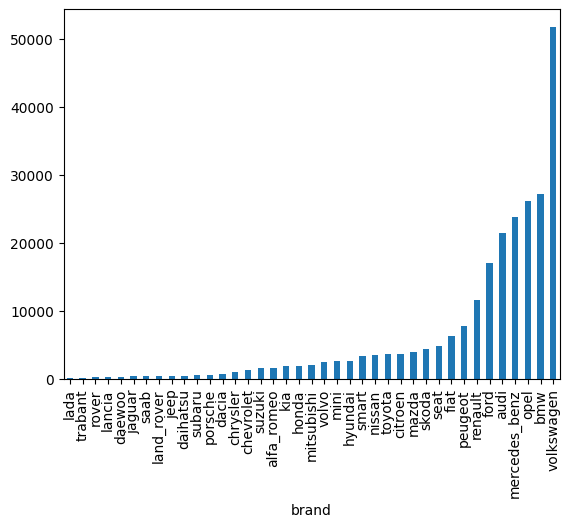

brand
daewoo            1121.234421
rover             1611.158915
daihatsu          2024.032692
trabant           2413.857820
lancia            2665.990291
renault           2727.548309
fiat              3189.243640
opel              3246.163573
mitsubishi        3449.403526
lada              3505.794521
peugeot           3563.548759
ford              3768.921740
citroen           3917.320033
smart             3934.039175
saab              4079.448441
chrysler          4195.290227
alfa_romeo        4210.117927
mazda             4224.874905
honda             4266.120788
subaru            4339.996255
suzuki            4441.807279
seat              4642.563125
nissan            4772.926328
volvo             4858.773204
toyota            5106.702404
volkswagen        5179.386989
kia               5498.188759
hyundai           5663.233248
chevrolet         5985.263281
dacia             6048.371706
skoda             6420.024368
mercedes_benz     6510.467116
bmw               6900.405541
audi

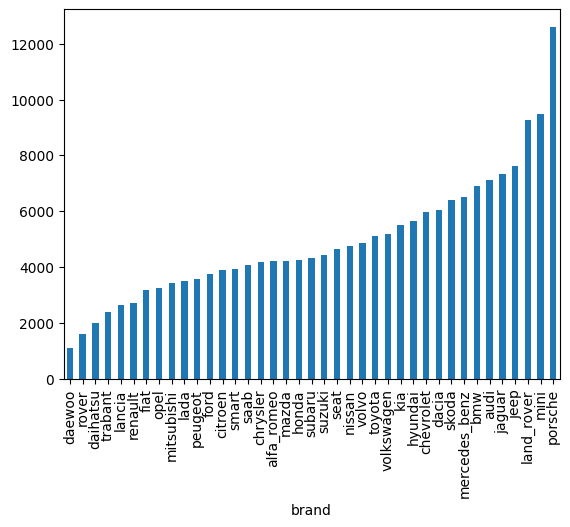

In [217]:
brand_month = cars_database.groupby('brand')['registrationmonth'].count().sort_values()
brand_price = cars_database.groupby('brand')['price'].mean().sort_values()

print(brand_month)
brand_month.plot(kind='bar')
plt.show()
print(brand_price)
brand_price.plot(kind='bar')
plt.show()

Podemos ver que tenemos mas carros volkswagen sin embargo no es la marca en promedio con el precio mas alto.
Tenemos 548 porsches y en promedio tienen un precio de $12mil y de los volkswagen tenemos 51787 vehiculos y en promedio tenemos tienen un precio de 5mil. 

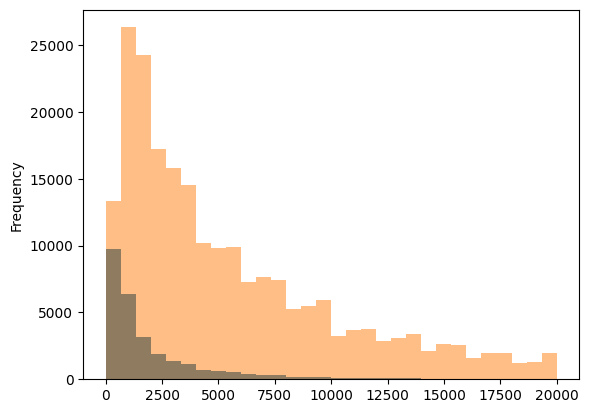

datecrawled          27800
price                27800
vehicletype          27800
registrationyear     27800
gearbox              27800
power                27800
model                27800
mileage              27800
registrationmonth    27800
fueltype             27800
brand                27800
notrepaired          27800
datecreated          27800
numberofpictures     27800
postalcode           27800
lastseen             27800
dtype: int64
datecrawled          217767
price                217767
vehicletype          217767
registrationyear     217767
gearbox              217767
power                217767
model                217767
mileage              217767
registrationmonth    217767
fueltype             217767
brand                217767
notrepaired          217767
datecreated          217767
numberofpictures     217767
postalcode           217767
lastseen             217767
dtype: int64


In [218]:
cars_database[cars_database['notrepaired'] == 'yes']['price'].plot(kind='hist', bins = 30)
cars_database[cars_database['notrepaired'] == 'no']['price'].plot(kind='hist', bins = 30,alpha = 0.5)
plt.show()
print(cars_database[cars_database['notrepaired'] == 'yes'].count())
print(cars_database[cars_database['notrepaired'] == 'no'].count())

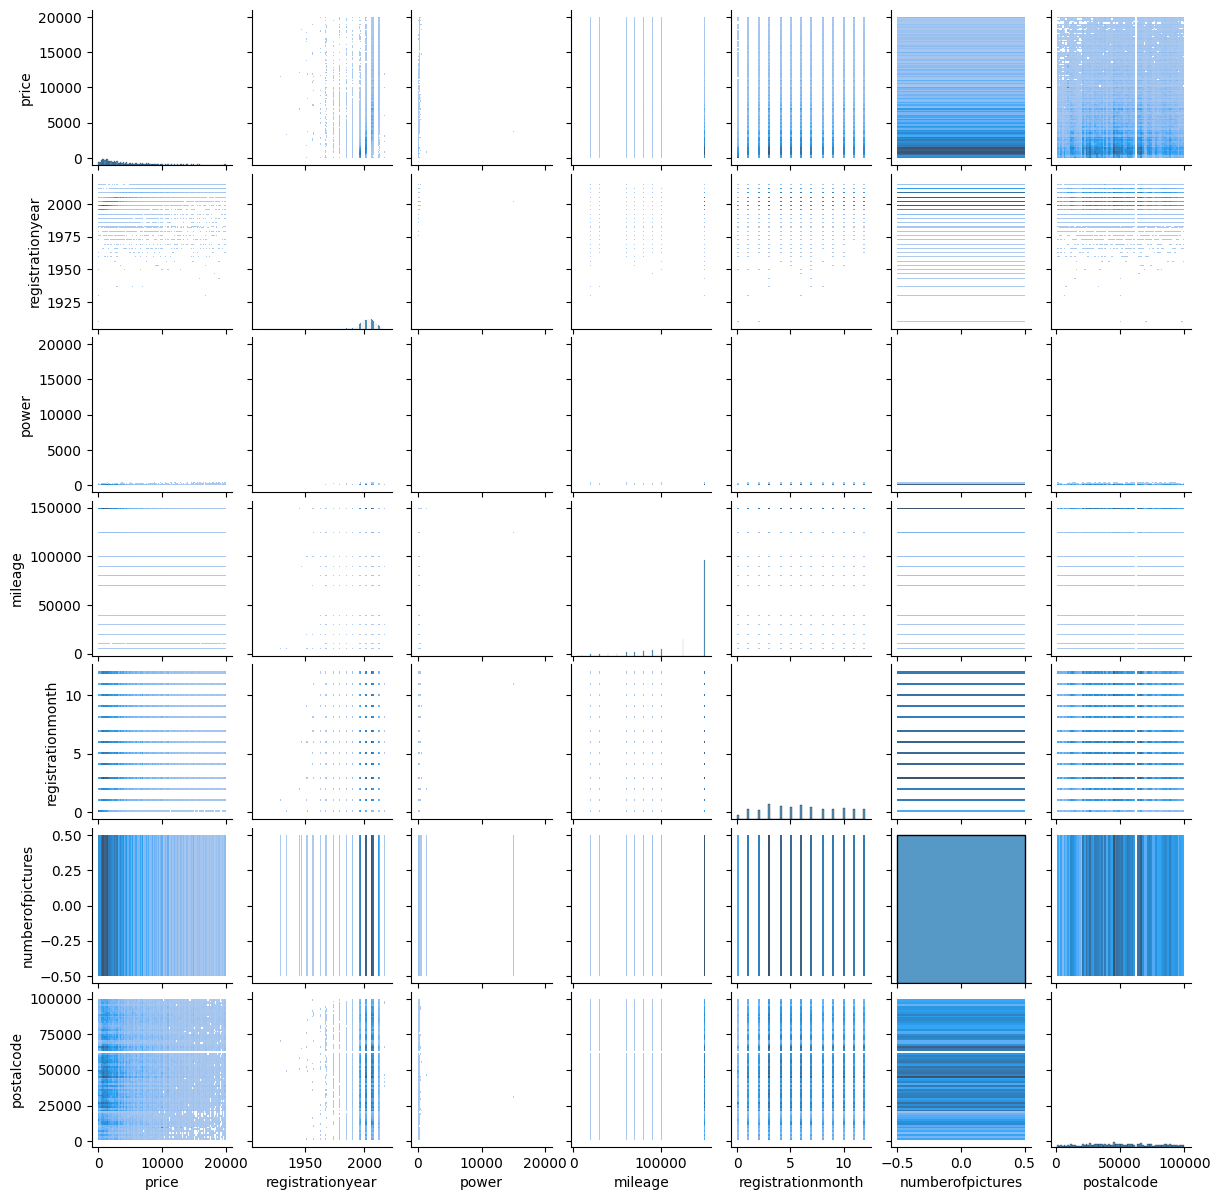

In [219]:
g = sns.pairplot(cars_database, kind='hist')
g.fig.set_size_inches(12, 12)

Aqui podemos ver como se relacionan las caracteristicas numericas unas con las otras. 

## Entrenamiento del modelo

Vamos a codificar las variables categoricas vehicletype, gearbox, model, fueltype, brand y notrepaired para poder probar diferentes modelos con diferentes hiperparámetros y revisar si hay alguna mejora en la prediccion del precio. 
Despues de tener todas las columnas categoricas con un valor numerico, estadarizaremos los valores para normalizar los datos y tengan una relacion mas cercana entre ellos.

Dividiremos los datos en catergorias y objetivo (features and target), después en datos de prueba y datos de validacion. 

In [220]:
display(cars_database.head(5)) 

,datecrawled,price,vehicletype,registrationyear,gearbox,power,model,mileage,registrationmonth,fueltype,brand,notrepaired,datecreated,numberofpictures,postalcode,lastseen
0,17/03/2016 16:54,1500.0,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
1,31/03/2016 17:25,3600.0,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17
2,04/04/2016 17:36,650.0,sedan,1995,manual,102,3er,150000,10,petrol,bmw,yes,04/04/2016 00:00,0,33775,06/04/2016 19:17
3,01/04/2016 20:48,2200.0,convertible,2004,manual,109,2_reihe,150000,8,petrol,peugeot,no,01/04/2016 00:00,0,67112,05/04/2016 18:18
4,21/03/2016 18:54,0.0,sedan,1980,manual,50,other,40000,7,petrol,volkswagen,no,21/03/2016 00:00,0,19348,25/03/2016 16:47


In [221]:
encoder = OrdinalEncoder()
columns_to_enconde = ['vehicletype','gearbox','model',
                      'fueltype','brand','notrepaired']

cars_database_encoded = cars_database[columns_to_enconde]
encoder.fit(cars_database_encoded)
cars_database_encoded = pd.DataFrame(encoder.transform(cars_database_encoded), columns= cars_database_encoded.columns)
display(cars_database_encoded.head(5))

,vehicletype,gearbox,model,fueltype,brand,notrepaired
0,5.0,1.0,116.0,6.0,37.0,0.0
1,5.0,1.0,101.0,2.0,31.0,0.0
2,4.0,1.0,11.0,6.0,2.0,1.0
3,1.0,1.0,8.0,6.0,25.0,0.0
4,4.0,1.0,166.0,6.0,37.0,0.0


In [222]:
columns_to_numerics = cars_database.select_dtypes(include=['number'])

scaler = StandardScaler()
cars_complete = pd.concat([columns_to_numerics,cars_database_encoded],axis= 'columns' )
#print(cars_complete.head())
features = cars_complete.drop(['price'], axis = 1)
target = cars_complete['price']
target = target.astype(float)

scaler.fit(features[features.columns])
features[features.columns] = scaler.transform(features[features.columns])
display(features.sample(5))

,registrationyear,power,mileage,registrationmonth,numberofpictures,postalcode,vehicletype,gearbox,model,fueltype,brand,notrepaired
134479,-2.095534,0.717317,-2.893707,-0.913680,0.0,1.847372,-0.118962,0.512218,0.816435,0.708053,-0.784186,-0.357295
131988,-0.635603,-0.422895,0.612277,1.385319,0.0,1.221437,0.350137,-1.952295,0.492431,-1.429835,1.286953,2.798811
121685,1.310971,0.100598,0.612277,-0.051555,0.0,1.465518,-0.118962,0.512218,-0.690890,-1.429835,-0.017098,-0.357295
121330,1.473186,-0.430066,0.612277,1.385319,0.0,-0.552884,0.350137,0.512218,0.915045,0.708053,1.286953,-0.357295
168542,0.013255,-0.207761,0.612277,-0.338930,0.0,-0.277688,-1.995360,0.512218,0.816435,-1.429835,-0.017098,-0.357295


In [223]:
feature_train ,  feature_valid , target_train, target_valid = train_test_split(features, target, test_size= 0.25, random_state= 12345)
print('Tenemos una division de datos con - >',feature_train.shape[0],
      'valores y ',feature_train.shape[1],'caracteristicas de entrenamiento.')
print('Tenemos una division de datos con - >',target_train.shape[0],
      'valores en el objetivo de entrenamiento.')

print('Tenemos una division de datos con - >',feature_valid.shape[0],
      'valores y ',feature_valid.shape[1],'caracteristicas de validacion.')
print('Tenemos una division de datos con - >',target_valid.shape[0],
      'valores en el objetivo de validacion.')

Tenemos una division de datos con - > 184175 valores y  12 caracteristicas de entrenamiento.
Tenemos una division de datos con - > 184175 valores en el objetivo de entrenamiento.
Tenemos una division de datos con - > 61392 valores y  12 caracteristicas de validacion.
Tenemos una division de datos con - > 61392 valores en el objetivo de validacion.


Ahora tenemos los datos divididos con solo 12 carateristicas, donde no se consideraron las columnas datecrawled, datecreated y lastseen ya que para una prediccion del precio del vehiculo es informacion basura que no ayudaría de ninguna forma a determinar el precio del vehículo. 

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy buen trabajo con el tratamiento y división de los datos, siempre es importante procesar los datos para enviar de forma correcta a los modelos 
</div>

A continuacion realizamos la prueba de cordura con el promedio de los precios y calculamos el RMSE para identificar cual sería un valor de error en caso de solo utilizar el promedio de todos los vehiculos a predecir. 

In [224]:
#Prueba de cordura.
predictions = pd.Series(target.mean() , index= target.index)
mse_cordura = mean_squared_error(target, predictions)
rmse_cordura = mse_cordura ** 0.5
print('Con un promedio de',target.mean(),'como la prediccion, la RMSE es -> $',rmse_cordura)

Con un promedio de 5125.680958760746 como la prediccion, la RMSE es -> $ 4718.459321059877


Acorde a la prueba de cordura podemos ver que tenemos $4,718.00 de error con los precios predichos a los reales. 
Dado que los precios mas altos en promedio son de $12,590.00 y en promedio de todos los precios tenemos como predicción $5125.68

Empecemos con la prediccion del arbol de decision donde jugaremos con el hiperparametro de la profundidad del arbol y tomaremos el tiempo en el que se tarda en identificar el menor error y asi la mejor profundidad. 

In [225]:
best_model_tree = None 
best_model_tree_2 = None 
best_rmse = 10000000
best_depth = 0
best_r2_tree = 0
best_depth_2 = 0

start_time_tree = time.time()
for depth in range(1,10):
    model_tree = DecisionTreeRegressor(max_depth= depth , random_state= 12345)
    model_tree.fit(feature_train, target_train)
    predictions_valid_tree = model_tree.predict(feature_valid)
    rmse_tree = mean_squared_error(target_valid, predictions_valid_tree) ** 0.5
    r2_tree = r2_score(target_valid, predictions_valid_tree)
    if rmse_tree < best_rmse:
        best_model_tree = model_tree
        best_rmse = rmse_tree
        best_depth = depth 
    if best_r2_tree < r2_tree:
        best_model_tree_2 = model_tree
        best_r2_tree = r2_tree
        best_depth_2 = depth

end_time_tree = time.time()

training_time_tree = end_time_tree - start_time_tree

In [226]:
print('La mejor profundidad es -> ',best_depth,'con el error minimo de $',best_rmse)
print('La mejor profundidad es -> ',best_depth_2,'con un r2 -> ',best_r2_tree)
print('Para encontrar la mejor profundidad del arbol nos tomo -> ',training_time_tree,' segundos')

La mejor profundidad es ->  9 con el error minimo de $ 2091.428176499196
La mejor profundidad es ->  9 con un r2 ->  0.8040038222797476
Para encontrar la mejor profundidad del arbol nos tomo ->  2.325913190841675  segundos


In [227]:
#Usando los mejores hiperparamentros. 
start_time_tree = time.time()
model_tree = DecisionTreeRegressor(max_depth= 9 , random_state= 12345)
model_tree.fit(feature_train, target_train)
predictions_valid_tree = model_tree.predict(feature_valid)
end_time_tree = time.time()

rmse_tree = mean_squared_error(target_valid, predictions_valid_tree) ** 0.5
r2_tree = r2_score(target_valid, predictions_valid_tree)
training_time_tree = end_time_tree - start_time_tree

print('Entonces el error mínimo con la mejor de profundidad 9 es de $',rmse_tree)
print('Y un R2 -> ',r2_tree)
print('Y tomo -> ',training_time_tree,' segundos para entrenar al modelo con la mejor profundidad.')

Entonces el error mínimo con la mejor de profundidad 9 es de $ 2091.428176499196
Y un R2 ->  0.8040038222797476
Y tomo ->  0.3786916732788086  segundos para entrenar al modelo con la mejor profundidad.


Ahora que usamos la mejor profundidad que es 9 y con un error minimo de $2091, lo que dista de 2mil en comparacion con la prueba de cordura, podemos decir que es una buena predicción. Este proceso de encontrar la mejor profundidad tomó 1.84 segundos, donde se fue entrenando el modelo con cada profundidad hasta llegar al 9. 
Al entrenar el modelo con la profunidad 9 solo nos tomó solo 0.34seg. 

Contiuamos con el modelo de RandomForestRegressor donde cambiaremos los hiperparamentros de la profundidad y los numeros de estimacion. Calcularemos el RMSE y el R2 para calificar e identificar el mejor modelo. 
Tambien mediremos el tiempo que requiere para entrenar cada modelo con diferentes hiperparametros para encontrar los mejores, despues volveremos a tomar el tiempo de entrenamiento con los mejores hiperparametros. 

In [228]:
best_model_forest = None 
best_rmse = 1000000
best_r2_forest = 0
best_depth = 0
best_est = 0
best_depth_2 = 0
best_est_2 = 0
start_time_forest = time.time()
for est in range(10,51,10):
    for depth in range(1,11):
        model_forest = RandomForestRegressor(max_depth= depth , random_state= 12345, n_estimators= est)
        model_forest.fit(feature_train, target_train)
        predictions_valid_forest = model_forest.predict(feature_valid)
        rmse_forest = mean_squared_error(target_valid, predictions_valid_forest) ** 0.5
        r2_forest = r2_score(target_valid, predictions_valid_forest)
        if rmse_forest < best_rmse:
            best_model_tree = model_forest
            best_rmse = rmse_forest
            best_depth = depth
            best_est = est
        if best_r2_forest < r2_forest:
            best_model_tree_2 = model_forest
            best_r2_forest = r2_forest
            best_depth_2 = depth
            best_est_2 = est
end_time_forest = time.time()

training_time_forest = end_time_forest - start_time_forest

In [229]:
print('La mejor profundidad es -> ',best_depth,'con un numero de estimado de',best_est,
      'con el error minimo es de $',best_rmse)

print('La mejor profundidad es -> ',best_depth_2,'con un numero de estimado de',best_est_2,
      'con un r2 ->',best_r2_forest)

print('Para encontrar la mejor profundidad y el numero de estimadores del bosque nos tomo -> ',
      training_time_forest/60,' mins')

La mejor profundidad es ->  10 con un numero de estimado de 50 con el error minimo es de $ 1925.9688295724113
La mejor profundidad es ->  10 con un numero de estimado de 50 con un r2 -> 0.8337888322569981
Para encontrar la mejor profundidad y el numero de estimadores del bosque nos tomo ->  4.031810307502747  mins


In [230]:
#Usando los mejores hiperparamentros. 
start_time_forest = time.time()
model_forest = RandomForestRegressor(max_depth= 10 , random_state= 12345, n_estimators= 50)
model_forest.fit(feature_train, target_train)
predictions_valid_forest = model_forest.predict(feature_valid)
rmse_forest = mean_squared_error(target_valid, predictions_valid_forest) ** 0.5
r2_forest = r2_score(target_valid, predictions_valid_forest)
end_time_forest = time.time()
training_time_forest = end_time_forest - start_time_forest

print('RMSE -> $', rmse_forest)
print('Con la mejor profundidad y el numero de estimadores del bosque nos tomo -> ',
      training_time_forest,' segs.')

RMSE -> $ 1925.9688295724113
Con la mejor profundidad y el numero de estimadores del bosque nos tomo ->  13.833136320114136  segs.


Entonces vemos que la mejor profundidad del bosque es de 10 con un numero de arboles de 50, tenemos un RMSE de $1926, el cual es mucho mejor que el de la prueba de cordura. Tenemos un tiempo de 3.6 mins donde se entrenaron varios modelos probando distintios valores de hiperparametros. Y solo tardamos 13.4segundos para entrenar el modelo ya con los mejores hiperparametros. 

Tambien intentaremos con el modelo de LinearRegression, donde obtuvimos un $3345 como error minimo, lo cual es mejor que el de la prueba de cordura, pero no es mejor que el de RandomForestRegressor. Tenemos un tiempo de ejucion de 0.2 segs lo cual es el mas rapido. 

In [231]:
start_time_regression = time.time()
model_regression = LinearRegression()
model_regression.fit(feature_train , target_train)
predictions_valid_regression = model_regression.predict(feature_valid)
end_time_regression = time.time()
resm_regression = mean_squared_error(target_valid , predictions_valid_regression)**0.5
r2_regression =  r2_score(target_valid, predictions_valid_regression)
training_time_regression = end_time_regression - start_time_regression
print('Tenemos un valor de R2 para el modelo de Linear Regression -> ',r2_regression)
print('Tenemos un valor de RESM para el modelo de Linear Regression -> $',resm_regression)
print('Para entrenar el modelo de liner regression nos tomo -> ',
      training_time_regression,' segs.')

Tenemos un valor de R2 para el modelo de Linear Regression ->  0.4986144332628185
Tenemos un valor de RESM para el modelo de Linear Regression -> $ 3345.0689008562485
Para entrenar el modelo de liner regression nos tomo ->  0.1698465347290039  segs.


Ahora vamos a realizar el modelo de SGDLinearRegression. 
Donde ocuparemos los hiperparemetros de tamaño del paso, numero de epocas, tamaño del lote y para evitar el sobreajuste usaremos el hiperparameto de peso de regularización.  

In [232]:
class SGDLinearRegression:
    def __init__(self, step_size, epochs, batch_size, reg_weight):
        self.step_size = step_size
        self.epochs = epochs
        self.batch_size = batch_size
        self.reg_weight = reg_weight
    
    def fit(self, train_feature, train_target):
        X = np.concatenate(
            (np.ones((train_feature.shape[0], 1)), train_feature), axis=1
        )
        y = train_target
        w = np.zeros(X.shape[1])
        
        for _ in range(self.epochs):
            batches_count = X.shape[0] // self.batch_size
            for i in range(batches_count):
                begin = i * self.batch_size
                end = (i + 1) * self.batch_size
                X_batch = X[begin:end, :]
                y_batch = y[begin:end]
                
                gradient = (
                    2 * X_batch.T.dot(X_batch.dot(w) - y_batch) / X_batch.shape[0]
                )
                reg = 2 * w.copy()
                reg[0] = 0
                gradient += self.reg_weight * reg
                w -= self.step_size * gradient

        self.w = w[1:]
        self.w0 = w[0]

    def predict(self, test_features):
        return test_features.dot(self.w) + self.w0
    

In [233]:
best_rmse_sgd = 100000
best_r2_sgd = 0

start_time_SGD = time.time()
for reg in np.arange(0.0, 0.5, 0.1):
    for batch in range(50, 150, 50):
        for epcho in range(2, 12, 2): 
                for step in np.arange(0.1, 0.3, 0.1):
                    model = SGDLinearRegression(step, epcho, batch, reg)
                    model.fit(feature_train, target_train)
                    pred_valid = model.predict(feature_valid)
                    resm_SGD = mean_squared_error(target_valid , pred_valid)**0.5
                    r2_SGD = r2_score(target_valid, pred_valid)
                    
                    if resm_SGD < best_rmse_sgd:
                        best_rmse_sgd = resm_SGD
                        best_reg_rmse = reg
                        best_batch_rmse = batch
                        best_epcho_rmse = epcho
                        best_step_rmse = step
                       
                    if best_r2_sgd < r2_SGD:
                        best_r2_sgd = r2_SGD
                        best_reg_r2 = reg
                        best_batch_r2 = batch
                        best_epcho_r2 = epcho
                        best_step_r2 = step

end_time_SGD = time.time()
training_time_SGD = end_time_SGD - start_time_SGD

In [234]:
print('Usando SGD Lineal Regression tenemos un R2 -> ',best_r2_sgd,'con los hiperparametros : \n el peso de regularizacion',
      best_reg_r2,'\ntamaño del lote', best_batch_r2,'\nnumero de epocas', best_epcho_r2,'\ntamaño del paso',best_step_r2)
print('\nUsando SGD Lineal Regression tenemos un RESM -> $',best_rmse_sgd,'con los hiperparametros : \n el peso de regularizacion',
      best_reg_rmse,'\ntamaño del lote', best_batch_rmse,'\nnumero de epocas', best_epcho_rmse,'\ntamaño del paso',best_step_rmse)
print('Este proceso tomó->', training_time_SGD/60,'mins')

Usando SGD Lineal Regression tenemos un R2 ->  0.5056989541649513 con los hiperparametros : 
 el peso de regularizacion 0.1 
tamaño del lote 100 
numero de epocas 2 
tamaño del paso 0.1

Usando SGD Lineal Regression tenemos un RESM -> $ 3321.352102764176 con los hiperparametros : 
 el peso de regularizacion 0.1 
tamaño del lote 100 
numero de epocas 2 
tamaño del paso 0.1
Este proceso tomó-> 2.2552509665489198 mins


<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Hola Jimena, por favor revisar la descripción del proyecto para que puedas completarlo. Además de entrenar los modelos debes calcular los tiempos de predicción y también los tiempos de entrenamiento.
    
Te pediría también por favor separar cada proceso en diferentes celdas, ya que por ejemplo esta última celda es muy extensa lo cual es dificil de seguir para cuando se requiera reproducir tu trabajo. 
    
Tampoco estás redactando conclusiones ni estás dejando comentarios sobre lo que estás haciendo y por qué lo estás haciendo.
    
No está de más mencionar que si se hace uso de herramientas de AI cómo ChatGPT para resolver el proyecto siempre hay que revisar el código generarlo y entenderlo correctamente, ya que estos modelos suelen alucinar las situaciones y puede que el código no sea el adecuado para el proyecto en cuestión.
</div>

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
Hola que tal! Gracias por los comentarios.
Ya agregué varios comentarios, los modelos que me faltaban y calculé el tiempo que toma ejecutarlos. 
Gracias por la recomendación de ChatGPT pero no use ninugna herramienta de AI, utilicé los ejercicios del curso para completar el modelo de SGD. 

</div>

**CatBoost**

Es un algoritmo de aprendizaje supervisado basado en árboles de decisión que utiliza el enfoque de gradient boosting (boosting por gradiente).
Este algoritmo se catergoriza por poder usar los datos categoricos, por lo que quise comparar los resultados entrenando el modelo una vez con los valores codificados y escalados, y otro modelo usando los valores originales categoricos. 

In [235]:
#Con caracterisiticas codificadas.

start_time_cat = time.time()
model_cat = CatBoostRegressor(loss_function="RMSE", iterations=150, random_seed = 12345, learning_rate=0.4, depth=10)
model_cat.fit(feature_train, target_train, verbose=10)
pred_valid_cat = model_cat.predict(feature_valid)
#print(pred_valid_cat)
end_time_cat = time.time()
training_time_cat = end_time_cat - start_time_cat

rmse = mean_squared_error(target_valid, pred_valid_cat) ** 0.5
r2 = r2_score(target_valid, pred_valid_cat)


0:	learn: 3446.6564319	total: 42.7ms	remaining: 6.36s
10:	learn: 1841.5192590	total: 279ms	remaining: 3.53s
20:	learn: 1730.5315701	total: 512ms	remaining: 3.14s
30:	learn: 1680.3682373	total: 739ms	remaining: 2.84s
40:	learn: 1644.7635617	total: 957ms	remaining: 2.54s
50:	learn: 1606.9783173	total: 1.18s	remaining: 2.3s
60:	learn: 1582.1519384	total: 1.41s	remaining: 2.05s
70:	learn: 1558.4653567	total: 1.63s	remaining: 1.81s
80:	learn: 1532.4591136	total: 1.84s	remaining: 1.57s
90:	learn: 1513.0871267	total: 2.06s	remaining: 1.34s
100:	learn: 1493.4809790	total: 2.29s	remaining: 1.11s
110:	learn: 1475.7334686	total: 2.5s	remaining: 879ms
120:	learn: 1456.5516813	total: 2.72s	remaining: 652ms
130:	learn: 1439.8515031	total: 2.94s	remaining: 427ms
140:	learn: 1427.5154422	total: 3.15s	remaining: 201ms
149:	learn: 1413.8970205	total: 3.35s	remaining: 0us


In [236]:
print(f"Tenemos un RMSE de: ${rmse}")
print(f"Tenemos un R² de: {r2}")
print(f"Durando unos {training_time_cat} segundos.")

Tenemos un RMSE de: $1630.0556481566523
Tenemos un R² de: 0.8809398146215889
Durando unos 3.5840368270874023 segundos.


Ahora vamos a dividir los datos con las caracteristicas categoricas sin modificar para poder entrenar el modelo de Catboost sin la modificacion y analizar como reacciona. 

In [237]:
feature_train_2, feature_valid_2, target_train_2, target_valid_2  = train_test_split(cars_database.drop(['price','datecrawled',
                                                                                                        'lastseen',
                                                                                                        'datecreated'],axis=1), 
                                                                                     cars_database['price'], 
                                                                                     test_size= 0.25, 
                                                                                     random_state= 12345)

print(feature_train_2.shape)
print(feature_valid_2.shape)
print(target_train_2.shape)
print(target_valid_2.shape)

(184175, 12)
(61392, 12)
(184175,)
(61392,)


In [238]:
categ_features = ['brand','fueltype','gearbox','model','notrepaired','vehicletype']
start_time_cat2 = time.time()
model_cat2 = CatBoostRegressor(loss_function="RMSE", 
                                       iterations=150, 
                                       random_seed = 12345, 
                                       learning_rate= 0.4, 
                                       depth=10)
model_cat2.fit(feature_train_2, target_train_2, cat_features=categ_features, verbose=10)
pred_valid_cat2 = model_cat2.predict(feature_valid_2)
end_time_cat2 = time.time()
training_time_cat2 = end_time_cat2 - start_time_cat2

rmse_cat2 = mean_squared_error(target_valid_2, pred_valid_cat2) ** 0.5
r2_cat2 = r2_score(target_valid_2, pred_valid_cat2)
       


0:	learn: 3447.3099645	total: 117ms	remaining: 17.4s
10:	learn: 1822.6708036	total: 1.27s	remaining: 16s
20:	learn: 1719.1611415	total: 2.46s	remaining: 15.1s
30:	learn: 1659.9472320	total: 3.69s	remaining: 14.2s
40:	learn: 1611.4021364	total: 4.87s	remaining: 12.9s
50:	learn: 1578.0019977	total: 6.06s	remaining: 11.8s
60:	learn: 1554.2839641	total: 7.24s	remaining: 10.6s
70:	learn: 1533.9184727	total: 8.42s	remaining: 9.37s
80:	learn: 1509.4534590	total: 9.65s	remaining: 8.22s
90:	learn: 1489.8802290	total: 10.9s	remaining: 7.06s
100:	learn: 1475.6507718	total: 12.2s	remaining: 5.9s
110:	learn: 1459.3021688	total: 13.4s	remaining: 4.72s
120:	learn: 1443.5802195	total: 14.7s	remaining: 3.53s
130:	learn: 1429.2150300	total: 16s	remaining: 2.32s
140:	learn: 1415.5379295	total: 17.2s	remaining: 1.09s
149:	learn: 1406.9727936	total: 18.3s	remaining: 0us


In [239]:
print(f"Tenemos un RMSE de: ${rmse_cat2}")
print(f"Tenemos un R² de: {r2_cat2}")
print(f"Durando unos {training_time_cat2} segundos.")

Tenemos un RMSE de: $1631.545619676096
Tenemos un R² de: 0.8807220584227821
Durando unos 18.989572763442993 segundos.


Podemos ver que ambos tienen un RMSE muy bajo de $1631, literalmente distando por $1. Donde el modelo sin caracteristicas categoricas es mejor por este $1.
Sin embargo en tiempo de entrenamiento hay 10 segundos de diferencia donde el modelo que es entrenado con las caracteristicas categóricas tarda 10 segundos mas que el modelo de utiliza los valores codificados.

Se utilizaron como hiperparametros: 
+ learning_rate = 0.4 
* depth = 10

**LightGBM** 

Esta es una biblioteca basada en gradient boosting diseñada para ser eficiente, rápida y escalable. Es especialmente útil para conjuntos de datos grandes con muchas características y alta dimensionalidad. LightGBM se basa en árboles de decisión y utiliza técnicas innovadoras como histogramas para mejorar la velocidad de entrenamiento.

In [240]:
start_time_lgb = time.time()
model_lgb = lgb.LGBMRegressor(
    objective="regression",  # Función de pérdida para regresión
    learning_rate=0.4,
    n_estimators=100,
    max_depth = 10,
    force_col_wise= "true"
)
model_lgb.fit(feature_train, target_train)

# Realizar predicciones
y_pred_lgb = model_lgb.predict(feature_valid)
end_time_cat2 = time.time()
training_time_lgb = end_time_cat2 - start_time_lgb
# Evaluar
rmse_lgb = mean_squared_error(target_valid, y_pred_lgb)**0.5
print(f"RMSE: {rmse_lgb}, con un tiempo de entrenamiento de {training_time_lgb} segs.")


[LightGBM] [Info] Total Bins 921
[LightGBM] [Info] Number of data points in the train set: 184175, number of used features: 11
[LightGBM] [Info] Start training from score 5125.976273
RMSE: 1667.3254249018369, con un tiempo de entrenamiento de 0.5297338962554932 segs.


Podemos ver que al utilizar los datos categoricos codificados y con hiperparametros de una tasa de aprendizaje con un 0.4, numero de arboles de 100 y una profundidad de los arboles de 10 tenemos un error minimo de $1668.99 y un tiempo de ejecución del entrenamiento de 0.66 segs. 

**XGBoost**

Entrenaremos ahora el modelo XGBoost donde usaremos las caracteristicas categoricas codificadas y los hiperparametros que usamos en el modelo anterior:

In [241]:
start_time_xbg = time.time()
model_xgb = xgb.XGBRegressor(
    objective = "reg:squarederror",
    n_estimators = 50,
    max_depth = 10,
    learning_rate = 0.4,
    random_state = 12345
)
model_xgb.fit(feature_train, target_train)

# Realizar predicciones
y_pred_xgb = model_xgb.predict(feature_valid)
end_time_xbg = time.time()
training_time_xgb = end_time_xbg - start_time_xbg
# Evaluar el modelo
rmse_xgb = mean_squared_error(target_valid, y_pred_xgb) ** 0.5
print(f"Tenemos un RMSE -> ${rmse_xgb}")
print(f"El modelo de XGBoost tomo un tiempo de -> {training_time_xgb} segundos")

Tenemos un RMSE -> $1647.6142314890965
El modelo de XGBoost tomo un tiempo de -> 0.7738070487976074 segundos


Tenemos un RMSE muy aceptable de $1647 en un tiempo de 0.49 segundos. 

# Conclusiones. 

A continuación podemos ver los diferentes modelos que se entrenaron con diferentes hiperparametros para obtener el menor RMSE: 

**Prueba de cordura**
* RMSE -> $4718.45

**DecisionTreeRegressor**
+ RMSE -> $2091.42
+ Tiempo de entrenamiento -> 0.34 segundos  \
Hiperparametro:
+ Profundidad máxima = 9

**RandomForestRegressor**
+ RMSE -> $1925.96
+ Tiempo de entrenamiento -> 16.56 segs. \
Hiperparametro:
+ Profundidad máxima = 9
+ Numero de arboles = 50

**Lineal Regression**
+ RMSE -> $3345.06
+ Tiempo de entrenamiento ->  0.2447974681854248  segs.

**SGD Lineal Regression**
+ RESM -> $3321.35 
+ Tiempo de entrenamiento -> 2.400539449850718 mins  \
Con los hiperparametros:
+ Peso de regularizacion 0.1 
+ Tamaño del lote = 100 
+ Numero de epocas = 2 
+ Tamaño del paso = 0.1

**CatBoost**
+ RMSE -> $1631.54
+ Tiempo de entrenamiento -> 13.52 segundos. \
Con los hiperparametros:
+ Con unas iteraciones =150
+ Profundidad máxima = 10
+ Tasa de aprendizaje  = 0.4

**LightGBM**
+ RMSE -> $1668.99
+ Tiempo de entrenamiento -> 0.66 segundos \
Con los hiperparametros:
+ Número de árboles = 100
+ Profundidad máxima de los árboles = 10
+ Tasa de aprendizaje  = 0.4

**XGBoost** 
+ RMSE -> $1647.61
+ Tiempo de entrenamiento -> 0.49 segundos \
Con los hiperparametros:
+ Número de árboles = 50
+ Profundidad máxima de los árboles = 10
+ Tasa de aprendizaje  = 0.4


Al analizar los datos podemos ver que de los modelos basado en gradient boosting con el menor RMSE es el CatBoost con un $1631.54, sin embargo es el que toma mas tiempo (13 segs.) y el que tomó menos tiempo y el RMSE tiene un buen valor minimo es el XGBoost con el RMSE de $1647.61 y un tiempo de entrenamiento 0.49 segs. 
Por lo que para predecir los precios de los vehiculos con una buena calidad en la empresa Rusty Bargain y de igual manera hacerlo en un buen tiempo, **se puede usar el modelo XGBoost.**